In [2]:
import polars as pl

In [3]:
df = pl.scan_csv(r'..\data\fifa26.csv.csv')
# df.head(3).collect()

In [4]:
# df.filter(
#     pl.col('player_id')==252371
# ).head(10).collect()

In [5]:
import polars as pl

# Supondo que você já tenha carregado o dataset
# df = pl.read_csv("seu_arquivo_fifa.csv")

dicionario_renomeacao = {
    # ---------------- DADOS BÁSICOS ---------------- #
    "player_id": "id_jogador",
    "player_url": "url_jogador",
    "fifa_version": "versao_fifa",
    "fifa_update": "atualizacao_fifa",
    "fifa_update_date": "data_atualizacao",
    "short_name": "nome_curto",
    "long_name": "nome_completo",
    "player_positions": "posicoes_jogador",
    "overall": "pontuacao_geral",
    "potential": "potencial",
    "value_eur": "valor_mercado_eur",
    "wage_eur": "salario_eur",
    "age": "idade",
    "dob": "data_nascimento",
    "height_cm": "altura_cm",
    "weight_kg": "peso_kg",
    "player_face_url": "url_rosto_jogador",

    # ---------------- CLUBE E LIGA ---------------- #
    "league_id": "id_liga",
    "league_name": "nome_liga",
    "league_level": "nivel_liga",
    "club_team_id": "id_clube",
    "club_name": "clube",
    "club_position": "posicao_clube",
    "club_jersey_number": "numero_camisa_clube",
    "club_loaned_from": "emprestado_de",
    "club_joined_date": "data_ingresso_clube",
    "club_contract_valid_until_year": "ano_fim_contrato",

    # ---------------- SELEÇÃO NACIONAL ---------------- #
    "nationality_id": "id_nacionalidade",
    "nationality_name": "nacionalidade",
    "nation_team_id": "id_selecao",
    "nation_position": "posicao_selecao",
    "nation_jersey_number": "numero_camisa_selecao",

    # ---------------- PERFIL DO JOGADOR ---------------- #
    "preferred_foot": "pe_preferencial",
    "weak_foot": "perna_ruim_estrelas",
    "skill_moves": "fintas_estrelas",
    "international_reputation": "reputacao_internacional",
    "work_rate": "dedicacao_ataque_defesa",
    "body_type": "tipo_fisico",
    "real_face": "rosto_real",
    "release_clause_eur": "clausula_rescisao_eur",
    "player_tags": "tags_jogador",
    "player_traits": "caracteristicas_jogador",

    # ---------------- ATRIBUTOS PRINCIPAIS ---------------- #
    "pace": "ritmo",
    "shooting": "chute",
    "passing": "passe",
    "dribbling": "drible_geral",
    "defending": "defesa_geral",
    "physic": "fisico_geral",

    # ---------------- ATRIBUTOS DE ATAQUE ---------------- #
    "attacking_crossing": "ataque_cruzamento",
    "attacking_finishing": "ataque_finalizacao",
    "attacking_heading_accuracy": "ataque_cabecenho",
    "attacking_short_passing": "ataque_passe_curto",
    "attacking_volleys": "ataque_voleio",

    # ---------------- HABILIDADES ---------------- #
    "skill_dribbling": "habilidade_drible",
    "skill_curve": "habilidade_curva",
    "skill_fk_accuracy": "habilidade_falta",
    "skill_long_passing": "habilidade_passe_longo",
    "skill_ball_control": "habilidade_controle_bola",

    # ---------------- MOVIMENTAÇÃO ---------------- #
    "movement_acceleration": "movimento_aceleracao",
    "movement_sprint_speed": "movimento_velocidade_final",
    "movement_agility": "movimento_agilidade",
    "movement_reactions": "movimento_reacao",
    "movement_balance": "movimento_equilibrio",

    # ---------------- FORÇA ---------------- #
    "power_shot_power": "forca_chute",
    "power_jumping": "forca_impulsao",
    "power_stamina": "forca_folego",
    "power_strength": "forca_fisica",
    "power_long_shots": "forca_chute_longe",

    # ---------------- MENTALIDADE ---------------- #
    "mentality_aggression": "mentalidade_agressividade",
    "mentality_interceptions": "mentalidade_interceptacao",
    "mentality_positioning": "mentalidade_posicionamento",
    "mentality_vision": "mentalidade_visao",
    "mentality_penalties": "mentalidade_penalti",
    "mentality_composure": "mentalidade_frieza",

    # ---------------- DEFESA ---------------- #
    "defending_marking_awareness": "defesa_nocao_marcacao",
    "defending_standing_tackle": "defesa_dividida_pe",
    "defending_sliding_tackle": "defesa_carrinho",

    # ---------------- GOLEIRO ---------------- #
    "goalkeeping_diving": "goleiro_mergulho",
    "goalkeeping_handling": "goleiro_manejo",
    "goalkeeping_kicking": "goleiro_chute",
    "goalkeeping_positioning": "goleiro_posicionamento",
    "goalkeeping_reflexes": "goleiro_reflexos",
    "goalkeeping_speed": "goleiro_velocidade",

    # ---------------- NOTAS POR POSIÇÃO EM CAMPO ---------------- #
    "ls": "nota_ls",
    "st": "nota_st",
    "rs": "nota_rs",
    "lw": "nota_lw",
    "lf": "nota_lf",
    "cf": "nota_cf",
    "rf": "nota_rf",
    "rw": "nota_rw",
    "lam": "nota_lam",
    "cam": "nota_cam",
    "ram": "nota_ram",
    "lm": "nota_lm",
    "lcm": "nota_lcm",
    "cm": "nota_cm",
    "rcm": "nota_rcm",
    "rm": "nota_rm",
    "lwb": "nota_lwb",
    "ldm": "nota_ldm",
    "cdm": "nota_cdm",
    "rdm": "nota_rdm",
    "rwb": "nota_rwb",
    "lb": "nota_lb",
    "lcb": "nota_lcb",
    "cb": "nota_cb",
    "rcb": "nota_rcb",
    "rb": "nota_rb",
    "gk": "nota_gk",
}

# Versão segura: renomeia apenas colunas que realmente existem no DataFrame
dicionario_renomeacao_existente = {
    coluna_antiga: coluna_nova
    for coluna_antiga, coluna_nova in dicionario_renomeacao.items()
    if coluna_antiga in df.columns
}

# Aplicando as mudanças no DataFrame
df = df.rename(dicionario_renomeacao_existente)

# Exibindo as colunas atualizadas para validar
# df.head(10).collect()

C:\Users\Giovani\AppData\Local\Temp\ipykernel_14600\2764054537.py:148: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  if coluna_antiga in df.columns


## Verificar um jogador

In [6]:
# df.filter(
#     pl.col('id_jogador')==252371
# ).collect()

## Verificando colunas

In [7]:
# df.columns

## Dropando colunas que nao vao pra modelagem

In [8]:
df = (
    df
    .drop('url_jogador',
          'versao_fifa',
          'atualizacao_fifa',
          'data_atualizacao', 
          'nome_curto',
          'nome_completo',
          'url_rosto_jogador'
          

          )
)

# Criando métricas derivadas

In [9]:
import polars as pl

# Colunas usadas para calcular a média dos atributos principais
colunas_atributos = [
    "ritmo",
    "chute",
    "passe",
    "drible_geral",
    "defesa_geral",
    "fisico_geral",
]

# Dicionário para agrupar as posições principais
grupos_posicao = {
    "GK": "Goleiro",

    "CB": "Defensor",
    "LB": "Defensor",
    "RB": "Defensor",
    "LWB": "Defensor",
    "RWB": "Defensor",

    "CDM": "Meio-campista",
    "CM": "Meio-campista",
    "LM": "Meio-campista",
    "RM": "Meio-campista",
    "CAM": "Meio-campista",

    "LW": "Atacante",
    "RW": "Atacante",
    "ST": "Atacante",
    "CF": "Atacante",
}

df = (
    df
    .with_columns([
        # Faixa etária
        pl.col("idade")
        .cut(
            breaks=[21, 25, 30, 35],
            labels=["U21", "22-25", "26-30", "31-35", "35+"]
        )
        .alias("faixa_etaria"),

        # Diferença entre potencial e pontuação atual
        (
            pl.col("potencial") - pl.col("pontuacao_geral")
        )
        .alias("crescimento_potencial"),

        # Média dos principais atributos técnicos/físicos
        pl.mean_horizontal([
            pl.col(col) for col in colunas_atributos
        ])
        .alias("media_atributos"),

        # Primeira posição listada como posição principal
        pl.col("posicoes_jogador")
        .str.split(",")
        .list.first()
        .str.strip_chars()
        .alias("posicao_principal"),
    ])
    .with_columns([
        # Agrupamento da posição principal
        pl.when(
            pl.col("posicao_principal").is_in(list(grupos_posicao.keys()))
        )
        .then(
            pl.col("posicao_principal").replace(grupos_posicao)
        )
        .otherwise(pl.lit("Outro"))
        .alias("tipo_posicao")
    ])
)

In [10]:
df.select([
    "id_jogador",
    "posicoes_jogador",
    "posicao_principal",
    "tipo_posicao",
    "idade",
    "faixa_etaria",
    "pontuacao_geral",
    "potencial",
    "crescimento_potencial",
    "media_atributos",
]).head(10).collect()

id_jogador,posicoes_jogador,posicao_principal,tipo_posicao,idade,faixa_etaria,pontuacao_geral,potencial,crescimento_potencial,media_atributos
i64,str,str,str,i64,enum,i64,i64,i64,f64
252371,"""CAM, CM""","""CAM""","""Meio-campista""",22,"""22-25""",90,94,4,83.666667
239053,"""CM, CDM, RB""","""CM""","""Meio-campista""",26,"""26-30""",89,90,1,84.666667
212622,"""CDM, RB, CM""","""CDM""","""Meio-campista""",30,"""26-30""",89,89,0,80.166667
235212,"""RB, RM""","""RB""","""Defensor""",26,"""26-30""",89,90,1,82.833333
224232,"""CM""","""CM""","""Meio-campista""",28,"""26-30""",87,87,0,80.833333
208128,"""CDM, CM""","""CDM""","""Meio-campista""",31,"""31-35""",86,86,0,79.166667
226268,"""LB, LM""","""LB""","""Defensor""",27,"""26-30""",85,85,0,80.0
239837,"""CM, CDM""","""CM""","""Meio-campista""",26,"""26-30""",87,88,1,78.666667
231866,"""CDM, CM""","""CDM""","""Meio-campista""",29,"""26-30""",90,90,0,81.0


# Descritivas

In [11]:
import polars as pl

# Número de linhas
n_linhas = df.select(pl.len().alias("n")).collect()["n"][0]


# -------------------------
# Overall statistics
# -------------------------
overall_stats = df.select([
    pl.col("pontuacao_geral").mean().alias("media"),
    pl.col("pontuacao_geral").median().alias("mediana"),
    pl.col("pontuacao_geral").std().alias("desvio_padrao"),
]).collect()

media_overall = overall_stats["media"][0]
mediana_overall = overall_stats["mediana"][0]
std_overall = overall_stats["desvio_padrao"][0]

print("Estatísticas da Pontuação Geral:")
print(f"Média: {media_overall:.1f}")
print(f"Mediana: {mediana_overall:.0f}")
print(f"Desvio padrão: {std_overall:.1f}")


# -------------------------
# Market value statistics
# -------------------------
valor_stats = df.select([
    pl.col("valor_mercado_eur").mean().alias("media"),
    pl.col("valor_mercado_eur").median().alias("mediana"),
    pl.col("valor_mercado_eur").sum().alias("total"),
]).collect()

media_valor = valor_stats["media"][0]
mediana_valor = valor_stats["mediana"][0]
total_valor = valor_stats["total"][0]

print("\nEstatísticas do Valor de Mercado:")
print(f"Média: €{media_valor:,.0f}")
print(f"Mediana: €{mediana_valor:,.0f}")
print(f"Total: €{total_valor:,.0f}")


# -------------------------
# Age statistics
# -------------------------
idade_stats = df.select([
    pl.col("idade").mean().alias("media"),
    pl.col("idade").min().alias("mais_novo"),
    pl.col("idade").max().alias("mais_velho"),
]).collect()

media_idade = idade_stats["media"][0]
idade_min = idade_stats["mais_novo"][0]
idade_max = idade_stats["mais_velho"][0]

print("\nEstatísticas de Idade:")
print(f"Média: {media_idade:.1f} anos")
print(f"Mais novo: {idade_min} anos")
print(f"Mais velho: {idade_max} anos")


# -------------------------
# Position distribution
# -------------------------
print("\nJogadores por Tipo de Posição:")

distribuicao_posicao = (
    df
    .group_by("tipo_posicao")
    .agg(
        pl.len().alias("frequencia")
    )
    .with_columns(
        (pl.col("frequencia") / n_linhas * 100).round(1).alias("percentual")
    )
    .sort("frequencia", descending=True)
    .collect()
)

for row in distribuicao_posicao.iter_rows(named=True):
    print(
        f"{row['tipo_posicao']}: "
        f"{row['frequencia']:,} "
        f"({row['percentual']:.1f}%)"
    )


# -------------------------
# Top leagues by average player value
# -------------------------
print("\nTop 5 Ligas por Valor Médio dos Jogadores:")

top_ligas = (
    df
    .group_by("nome_liga")
    .agg([
        pl.col("valor_mercado_eur").mean().alias("media_valor_mercado"),
        pl.len().alias("qtd_jogadores"),
    ])
    .filter(pl.col("qtd_jogadores") > 50)
    .sort("media_valor_mercado", descending=True)
    .head(5)
    .collect()
)

for row in top_ligas.iter_rows(named=True):
    print(
        f"{row['nome_liga']}: "
        f"€{row['media_valor_mercado']:,.0f} "
        f"({row['qtd_jogadores']} jogadores)"
    )


# -------------------------
# Top clubs by average overall rating
# -------------------------
print("\nTop 5 Clubes por Pontuação Geral Média:")

top_clubes = (
    df
    .group_by("clube")
    .agg([
        pl.col("pontuacao_geral").mean().alias("media_pontuacao_geral"),
        pl.len().alias("qtd_jogadores"),
    ])
    .filter(pl.col("qtd_jogadores") > 15)
    .sort("media_pontuacao_geral", descending=True)
    .head(5)
    .collect()
)

for row in top_clubes.iter_rows(named=True):
    print(
        f"{row['clube']}: "
        f"{row['media_pontuacao_geral']:.1f} "
        f"({row['qtd_jogadores']} jogadores)"
    )

Estatísticas da Pontuação Geral:
Média: 65.8
Mediana: 66
Desvio padrão: 7.0

Estatísticas do Valor de Mercado:
Média: €2,931,633
Mediana: €1,000,000
Total: €53,956,711,956

Estatísticas de Idade:
Média: 25.2 anos
Mais novo: 16 anos
Mais velho: 44 anos

Jogadores por Tipo de Posição:
Meio-campista: 6,864 (37.3%)
Defensor: 6,116 (33.2%)
Atacante: 3,363 (18.3%)
Goleiro: 2,062 (11.2%)

Top 5 Ligas por Valor Médio dos Jogadores:
Premier League: €16,281,502 (609 jogadores)
La Liga: €12,478,764 (554 jogadores)
Serie A: €7,764,709 (687 jogadores)
Ligue 1: €7,525,369 (488 jogadores)
Bundesliga: €5,819,925 (866 jogadores)

Top 5 Clubes por Pontuação Geral Média:
Arsenal: 82.6 (24 jogadores)
Manchester City: 81.0 (26 jogadores)
Paris Saint-Germain: 80.8 (23 jogadores)
Inter: 80.2 (25 jogadores)
Atlético Madrid: 80.2 (25 jogadores)


# Graficos e Distribuicoes

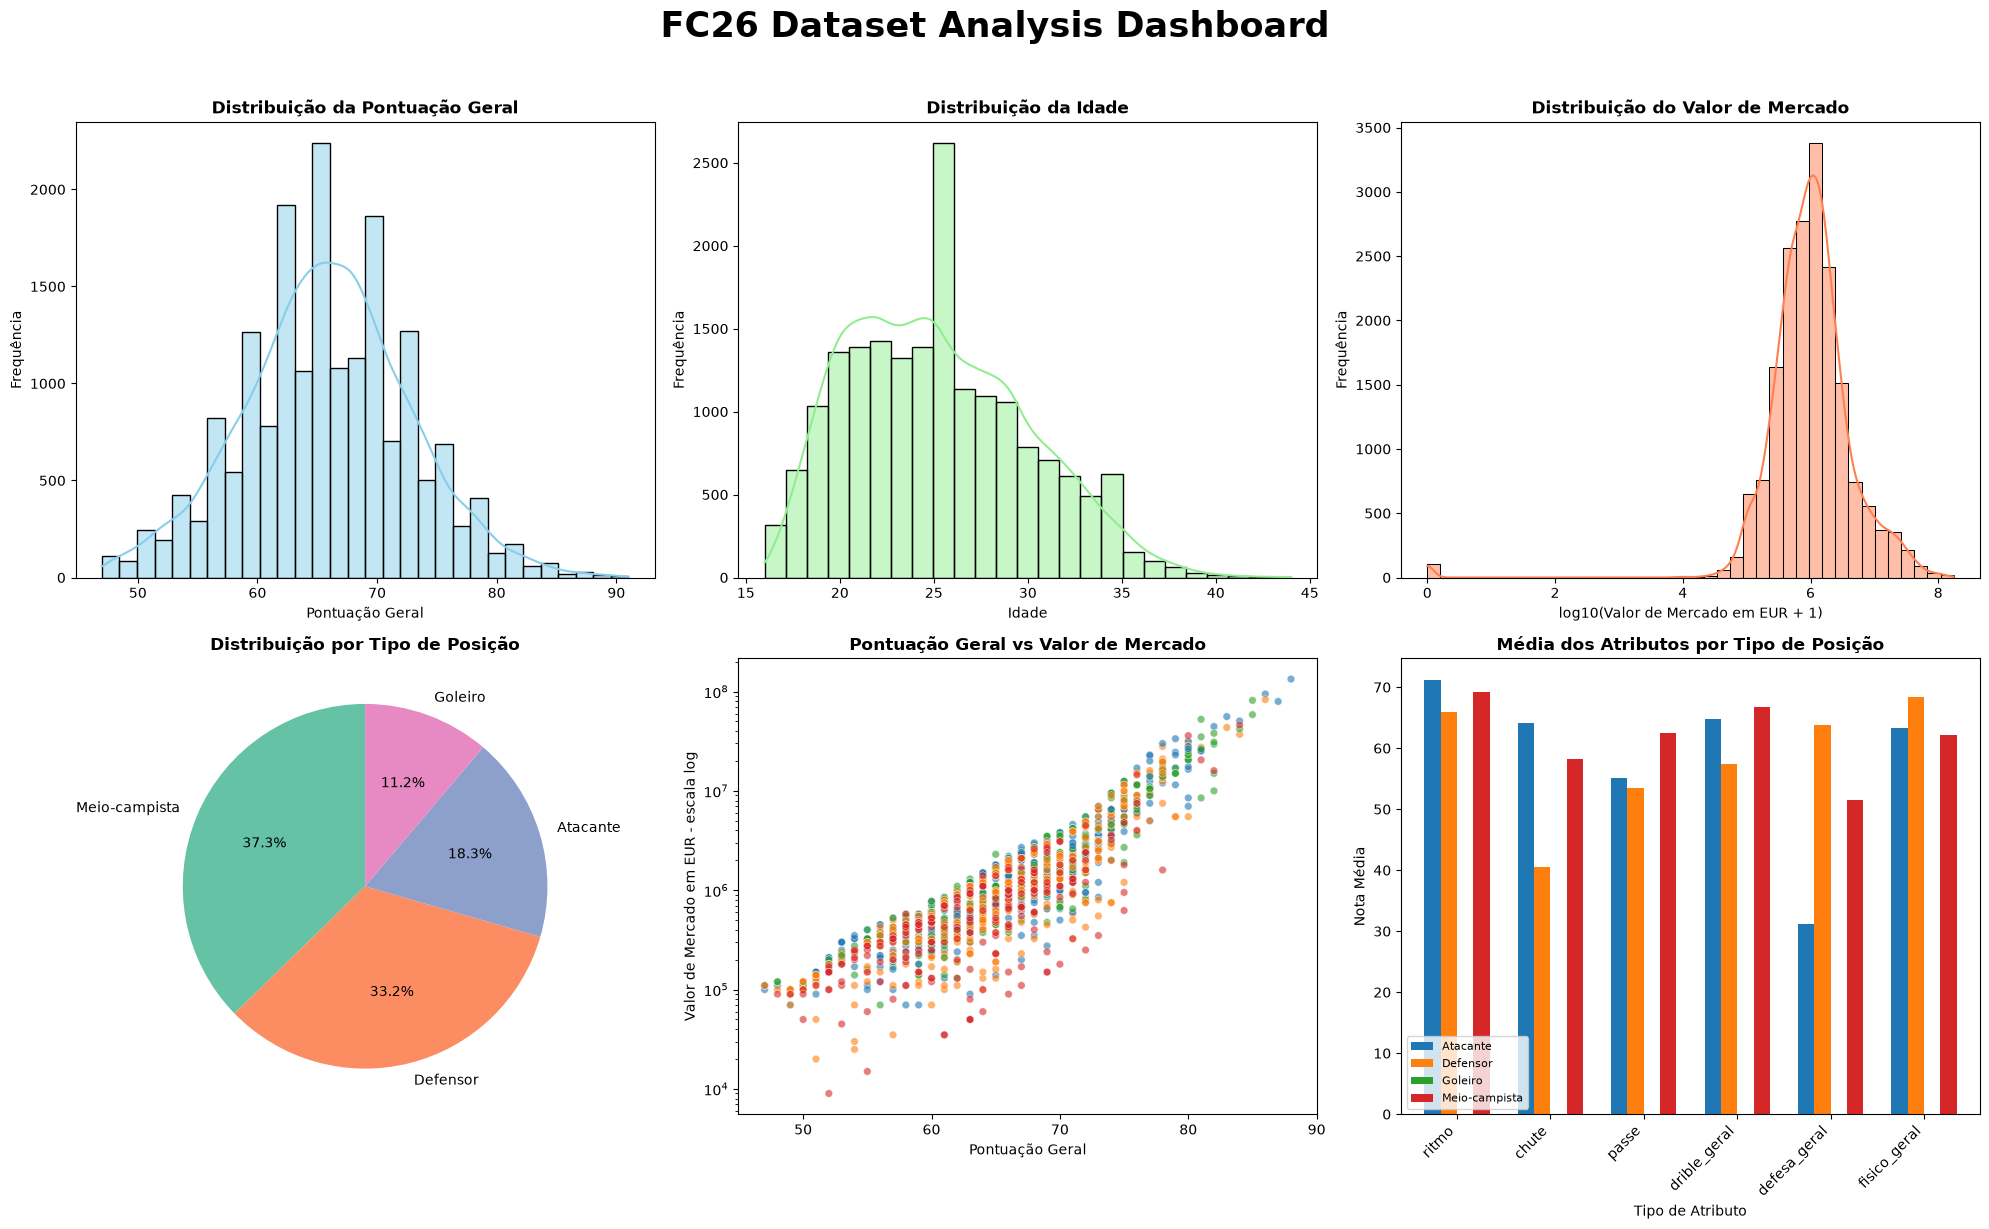

In [12]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Se df for LazyFrame, transforma em DataFrame normal para plotar
if isinstance(df, pl.LazyFrame):
    df_plot = df.collect()
else:
    df_plot = df.clone()

# Colunas de atributos principais já renomeadas
colunas_atributos = [
    "ritmo",
    "chute",
    "passe",
    "drible_geral",
    "defesa_geral",
    "fisico_geral",
]

# =========================
# VISUALIZAÇÕES
# =========================

fig = plt.figure(figsize=(20, 12))
fig.suptitle(
    "FC26 Dataset Analysis Dashboard",
    fontsize=25,
    fontweight="bold",
    y=1.02
)

# 1. Distribuição da pontuação geral
ax1 = plt.subplot(2, 3, 1)

sns.histplot(
    df_plot["pontuacao_geral"].drop_nulls().to_numpy(),
    bins=30,
    kde=True,
    color="skyblue",
    ax=ax1
)

ax1.set_title("Distribuição da Pontuação Geral", fontweight="bold")
ax1.set_xlabel("Pontuação Geral")
ax1.set_ylabel("Frequência")


# 2. Distribuição da idade
ax2 = plt.subplot(2, 3, 2)

sns.histplot(
    df_plot["idade"].drop_nulls().to_numpy(),
    bins=25,
    kde=True,
    color="lightgreen",
    ax=ax2
)

ax2.set_title("Distribuição da Idade", fontweight="bold")
ax2.set_xlabel("Idade")
ax2.set_ylabel("Frequência")


# 3. Distribuição do valor de mercado em escala log
ax3 = plt.subplot(2, 3, 3)

valor_mercado = (
    df_plot
    .select(pl.col("valor_mercado_eur").fill_null(0))
    .to_series()
    .to_numpy()
)

valor_log = np.log10(valor_mercado + 1)

sns.histplot(
    valor_log,
    bins=40,
    kde=True,
    color="coral",
    ax=ax3
)

ax3.set_title("Distribuição do Valor de Mercado", fontweight="bold")
ax3.set_xlabel("log10(Valor de Mercado em EUR + 1)")
ax3.set_ylabel("Frequência")


# 4. Distribuição por tipo de posição
ax4 = plt.subplot(2, 3, 4)

contagem_posicao = (
    df_plot
    .group_by("tipo_posicao")
    .agg(
        pl.len().alias("frequencia")
    )
    .sort("frequencia", descending=True)
)

labels_posicao = contagem_posicao["tipo_posicao"].to_list()
valores_posicao = contagem_posicao["frequencia"].to_list()

colors = sns.color_palette("Set2", len(valores_posicao))

ax4.pie(
    valores_posicao,
    labels=labels_posicao,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors
)

ax4.set_title("Distribuição por Tipo de Posição", fontweight="bold")


# 5. Pontuação geral vs valor de mercado
ax5 = plt.subplot(2, 3, 5)

n_amostra = min(2000, df_plot.height)

amostra = (
    df_plot
    .select([
        "pontuacao_geral",
        "valor_mercado_eur",
        "tipo_posicao",
    ])
    .drop_nulls()
    .sample(n=n_amostra, seed=42)
    .to_pandas()
)

sns.scatterplot(
    data=amostra,
    x="pontuacao_geral",
    y="valor_mercado_eur",
    hue="tipo_posicao",
    alpha=0.6,
    s=30,
    ax=ax5,
    legend=False
)

ax5.set_yscale("log")
ax5.set_title("Pontuação Geral vs Valor de Mercado", fontweight="bold")
ax5.set_xlabel("Pontuação Geral")
ax5.set_ylabel("Valor de Mercado em EUR - escala log")


# 6. Média dos atributos por tipo de posição
ax6 = plt.subplot(2, 3, 6)

media_atributos_posicao = (
    df_plot
    .group_by("tipo_posicao")
    .agg([
        pl.col(col).mean().alias(col)
        for col in colunas_atributos
    ])
    .sort("tipo_posicao")
    .to_pandas()
)

media_atributos_posicao = media_atributos_posicao.set_index("tipo_posicao")

media_atributos_posicao.T.plot(
    kind="bar",
    ax=ax6,
    width=0.7
)

ax6.set_title("Média dos Atributos por Tipo de Posição", fontweight="bold")
ax6.set_xlabel("Tipo de Atributo")
ax6.set_ylabel("Nota Média")
ax6.legend(loc="lower left", fontsize=8)
ax6.set_xticklabels(
    ax6.get_xticklabels(),
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

In [13]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Se df ainda estiver como LazyFrame, materializa para DataFrame
if isinstance(df, pl.LazyFrame):
    df_plot = df.collect()
else:
    df_plot = df.clone()

# Colunas dos atributos principais
colunas_atributos = [
    "ritmo",
    "chute",
    "passe",
    "drible_geral",
    "defesa_geral",
    "fisico_geral",
]

# Ordem das faixas etárias para os gráficos
ordem_faixa_etaria = ["U21", "22-25", "26-30", "31-35", "35+"]

# Garantindo que as variáveis derivadas existem
# Rode isso caso ainda não tenha criado faixa_etaria, crescimento_potencial etc.
if "faixa_etaria" not in df_plot.columns:
    df_plot = df_plot.with_columns(
        pl.col("idade")
        .cut(
            breaks=[21, 25, 30, 35],
            labels=["U21", "22-25", "26-30", "31-35", "35+"]
        )
        .alias("faixa_etaria")
    )

if "crescimento_potencial" not in df_plot.columns:
    df_plot = df_plot.with_columns(
        (pl.col("potencial") - pl.col("pontuacao_geral"))
        .alias("crescimento_potencial")
    )

if "media_atributos" not in df_plot.columns:
    df_plot = df_plot.with_columns(
        pl.mean_horizontal([pl.col(col) for col in colunas_atributos])
        .alias("media_atributos")
    )

C:\Users\Giovani\AppData\Local\Temp\ipykernel_14600\3903134514.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Giovani\AppData\Local\Temp\ipykernel_14600\3903134514.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Giovani\AppData\Local\Temp\ipykernel_14600\3903134514.py:130: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\Giovani\AppData\Local\Temp\ipykernel_14600\3903134514.py:160: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` v

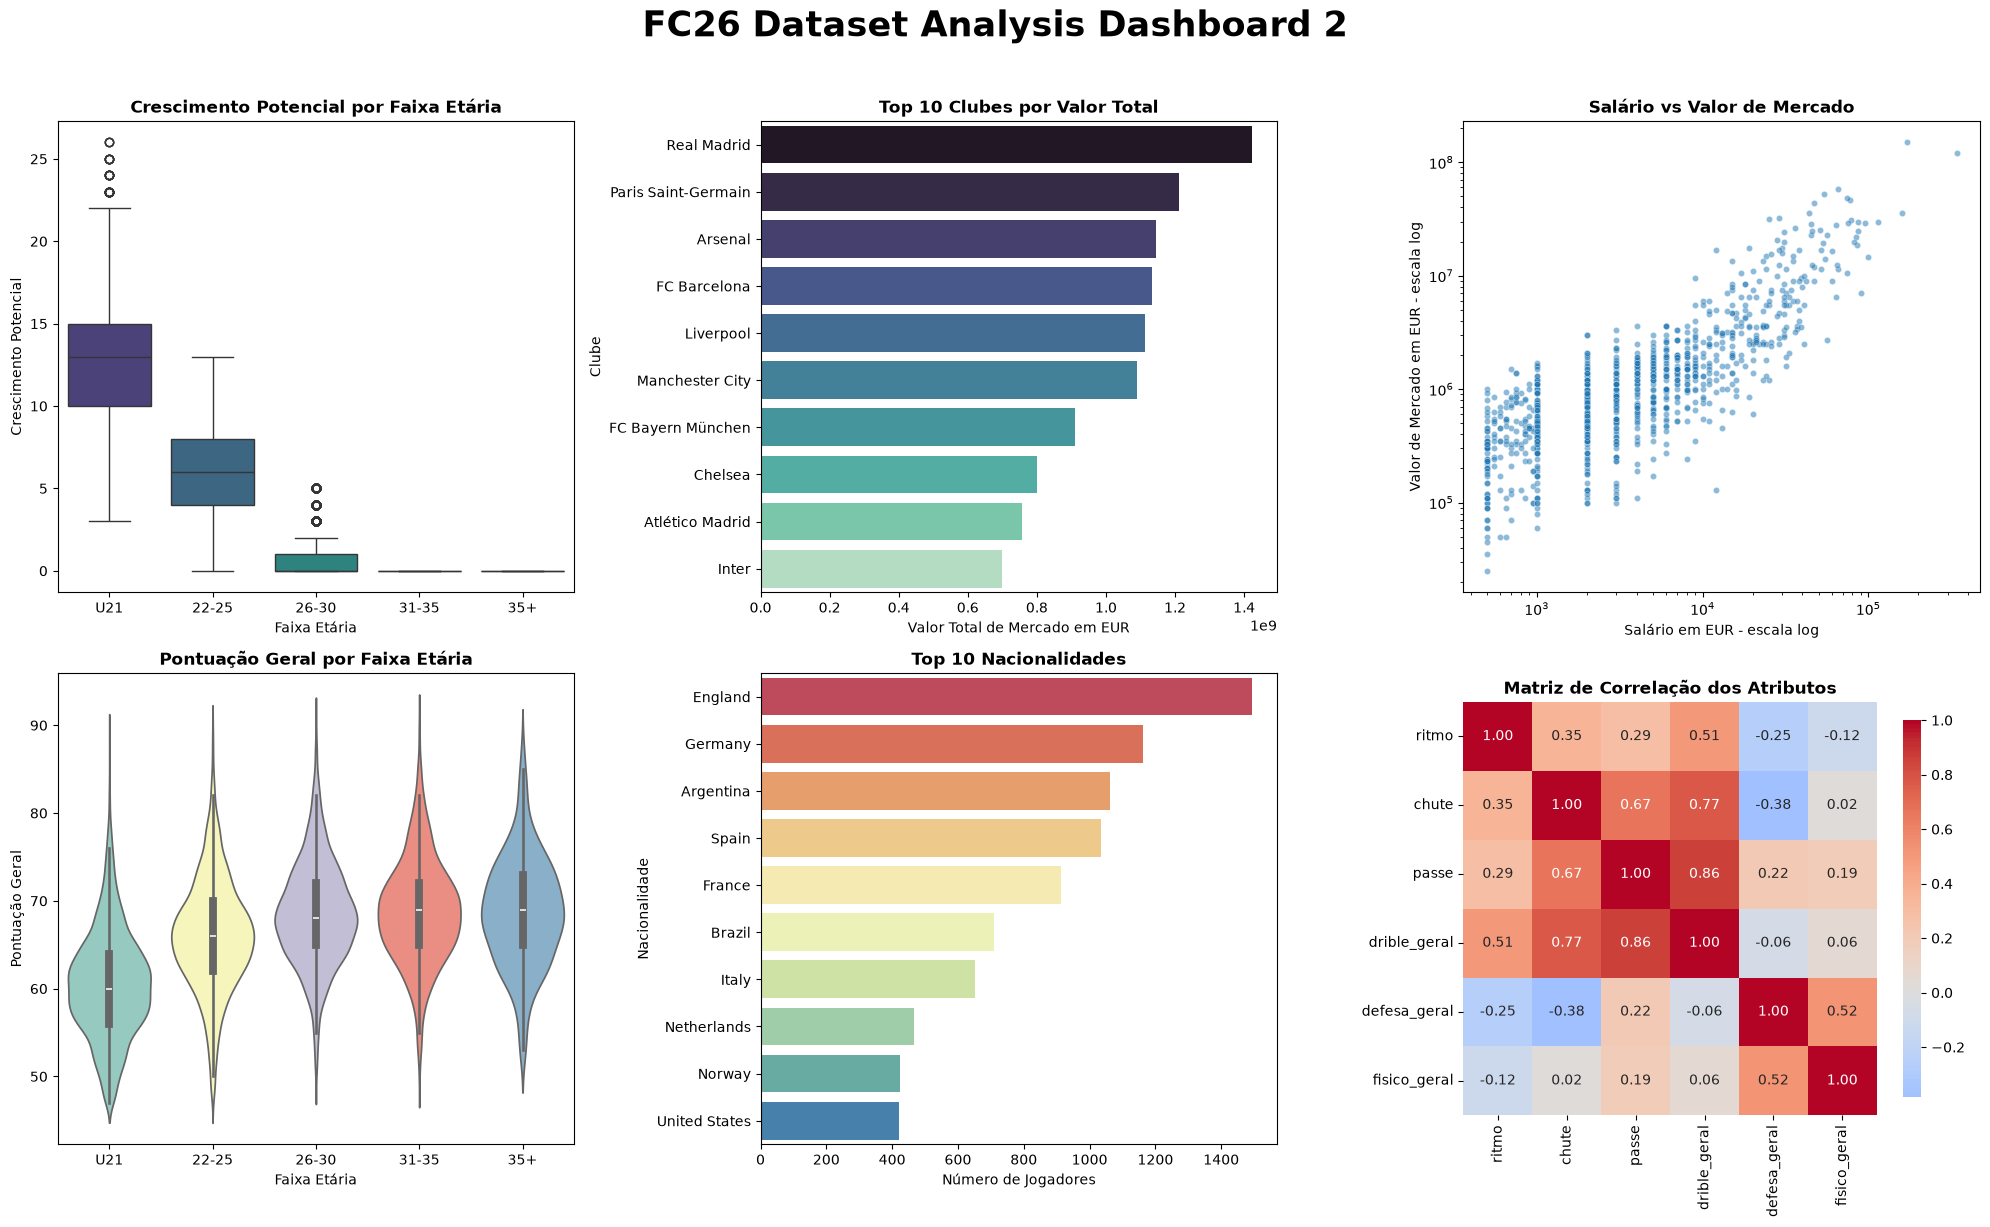

In [14]:
# =========================
# DASHBOARD 2
# =========================

fig = plt.figure(figsize=(20, 12))
fig.suptitle(
    "FC26 Dataset Analysis Dashboard 2",
    fontsize=25,
    fontweight="bold",
    y=1.02
)

# --------------------------------------------------
# 7. Crescimento potencial por faixa etária
# --------------------------------------------------
ax7 = plt.subplot(2, 3, 1)

dados_idade_potencial = (
    df_plot
    .select([
        "faixa_etaria",
        "crescimento_potencial"
    ])
    .drop_nulls()
    .to_pandas()
)

sns.boxplot(
    data=dados_idade_potencial,
    x="faixa_etaria",
    y="crescimento_potencial",
    order=ordem_faixa_etaria,
    palette="viridis",
    ax=ax7
)

ax7.set_title("Crescimento Potencial por Faixa Etária", fontweight="bold")
ax7.set_xlabel("Faixa Etária")
ax7.set_ylabel("Crescimento Potencial")


# --------------------------------------------------
# 8. Top 10 clubes por valor total de mercado
# --------------------------------------------------
ax8 = plt.subplot(2, 3, 2)

top_clubes_valor = (
    df_plot
    .group_by("clube")
    .agg(
        pl.col("valor_mercado_eur")
        .sum()
        .alias("valor_total_mercado")
    )
    .sort("valor_total_mercado", descending=True)
    .head(10)
    .to_pandas()
)

sns.barplot(
    data=top_clubes_valor,
    x="valor_total_mercado",
    y="clube",
    palette="mako",
    ax=ax8
)

ax8.set_title("Top 10 Clubes por Valor Total", fontweight="bold")
ax8.set_xlabel("Valor Total de Mercado em EUR")
ax8.set_ylabel("Clube")


# --------------------------------------------------
# 9. Relação entre salário e valor de mercado
# --------------------------------------------------
ax9 = plt.subplot(2, 3, 3)

dados_salario_valor = (
    df_plot
    .select([
        "salario_eur",
        "valor_mercado_eur"
    ])
    .drop_nulls()
    .filter(
        (pl.col("salario_eur") > 0) &
        (pl.col("valor_mercado_eur") > 0)
    )
)

n_amostra = min(1000, dados_salario_valor.height)

amostra_salario_valor = (
    dados_salario_valor
    .sample(n=n_amostra, seed=42)
    .to_pandas()
)

sns.scatterplot(
    data=amostra_salario_valor,
    x="salario_eur",
    y="valor_mercado_eur",
    alpha=0.5,
    s=20,
    ax=ax9
)

ax9.set_xscale("log")
ax9.set_yscale("log")
ax9.set_title("Salário vs Valor de Mercado", fontweight="bold")
ax9.set_xlabel("Salário em EUR - escala log")
ax9.set_ylabel("Valor de Mercado em EUR - escala log")


# --------------------------------------------------
# 10. Pontuação geral por faixa etária
# --------------------------------------------------
ax10 = plt.subplot(2, 3, 4)

dados_idade_overall = (
    df_plot
    .select([
        "faixa_etaria",
        "pontuacao_geral"
    ])
    .drop_nulls()
    .to_pandas()
)

sns.violinplot(
    data=dados_idade_overall,
    x="faixa_etaria",
    y="pontuacao_geral",
    order=ordem_faixa_etaria,
    palette="Set3",
    ax=ax10
)

ax10.set_title("Pontuação Geral por Faixa Etária", fontweight="bold")
ax10.set_xlabel("Faixa Etária")
ax10.set_ylabel("Pontuação Geral")


# --------------------------------------------------
# 11. Top 10 nacionalidades
# --------------------------------------------------
ax11 = plt.subplot(2, 3, 5)

top_nacionalidades = (
    df_plot
    .group_by("nacionalidade")
    .agg(
        pl.len().alias("qtd_jogadores")
    )
    .sort("qtd_jogadores", descending=True)
    .head(10)
    .to_pandas()
)

sns.barplot(
    data=top_nacionalidades,
    x="qtd_jogadores",
    y="nacionalidade",
    palette="Spectral",
    ax=ax11
)

ax11.set_title("Top 10 Nacionalidades", fontweight="bold")
ax11.set_xlabel("Número de Jogadores")
ax11.set_ylabel("Nacionalidade")


# --------------------------------------------------
# 12. Matriz de correlação dos atributos principais
# --------------------------------------------------
ax12 = plt.subplot(2, 3, 6)

matriz_correlacao = (
    df_plot
    .select(colunas_atributos)
    .drop_nulls()
    .corr()
    .to_pandas()
)

# Ajustando índice para aparecer o nome das variáveis no eixo y
matriz_correlacao.index = colunas_atributos

sns.heatmap(
    matriz_correlacao,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    ax=ax12,
    cbar_kws={"shrink": 0.8}
)

ax12.set_title("Matriz de Correlação dos Atributos", fontweight="bold")

plt.tight_layout()
plt.show()

# Dropando Colunas q vazam informacoes

In [15]:
df = (
    df
    .drop(
        ''
    )
)